<a href="https://colab.research.google.com/github/vahid-am/AI-Projects/blob/main/LLG_article_Spin_Chain_Code_Nearest_Neighbor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running h = -2.50
Running h = -2.25
Running h = -2.00
Running h = -1.75
Running h = -1.50
Running h = -1.25
Running h = -1.00
Running h = -0.75
Running h = -0.50
Running h = -0.25
Running h = 0.00
Running h = 0.25
Running h = 0.50
Running h = 0.75
Running h = 1.00
Running h = 1.25
Running h = 1.50
Running h = 1.75
Running h = 2.00
Running h = 2.25
Running h = 2.50


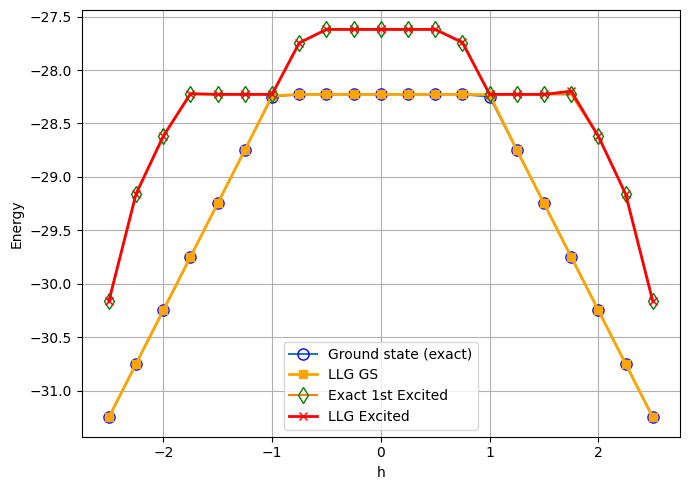

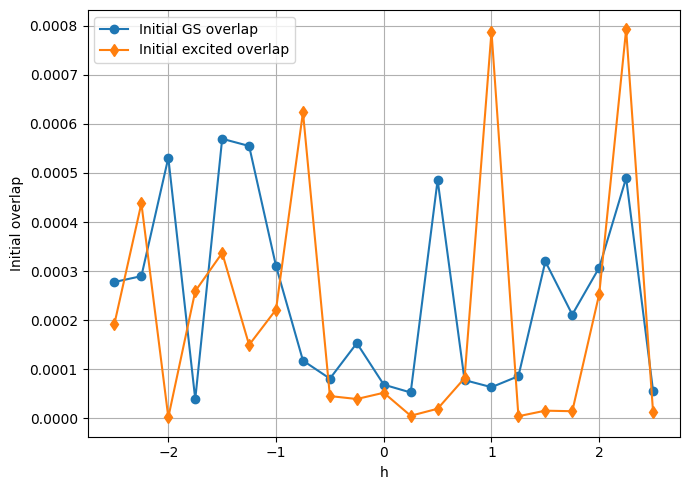

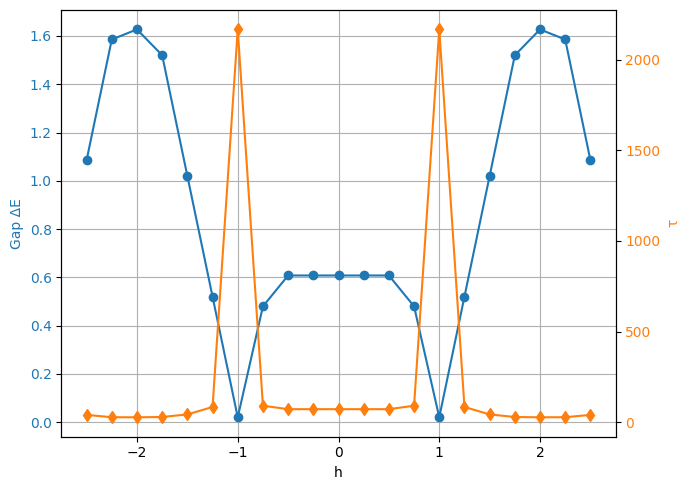

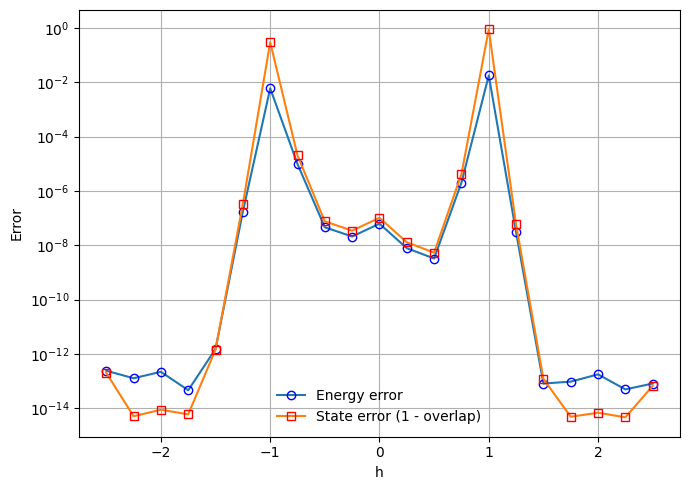

In [ ]:
import numpy as np
from numpy.linalg import norm
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
from numba import njit

# ==================================================
# NUMBA: Heisenberg NN Hamiltonian action
# ==================================================
@njit(fastmath=True, nogil=True)
def apply_heisenberg_nn_numba(psi, N, Delta, h):
    dim = psi.shape[0]
    out = np.zeros_like(psi)

    for state in range(dim):
        amp = psi[state]
        if amp == 0.0:
            continue

        diag = 0.0

        # Magnetic field
        for i in range(N):
            si = (state >> i) & 1
            diag -= h * (1.0 if si == 0 else -1.0)

        # Interaction
        for i in range(N - 1):
            si = (state >> i) & 1
            sj = (state >> (i + 1)) & 1

            diag += Delta * (1.0 if si == sj else -1.0)

            if si != sj:
                flipped = state ^ (1 << i) ^ (1 << (i + 1))
                out[flipped] += 2.0 * amp

        out[state] += diag * amp

    return out


# ==================================================
# Ground and First Excited State
# ==================================================
def lowest_states(N, Delta, h, tol=1e-12):
    dim = 2**N

    def matvec(v):
        return apply_heisenberg_nn_numba(v, N, Delta, h)

    H_op = LinearOperator((dim, dim), matvec=matvec, dtype=np.complex128)
    k = min(10, dim)
    E, psi = eigsh(H_op, k=k, which="SA", tol=1e-10)

    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    E_gs = E[0]
    gs_indices = np.where(np.abs(E - E_gs) < tol)[0]
    psi_gs_list = psi[:, gs_indices]

    for i in range(len(E)):
        if i not in gs_indices:
            E_ex1 = E[i]
            psi_ex1 = psi[:, i]
            break

    return E_gs, psi_gs_list, E_ex1, psi_ex1


# ==================================================
# κ-flow evolution
# ==================================================
def propagate_kappa_pure(psi0, N, Delta, h, kappa, hbar, t_final, dt):
    psi = psi0.copy()
    steps = int(t_final / dt)
    coeff = (-1j - kappa) / (hbar * (1.0 + kappa**2))

    for _ in range(steps):
        Hpsi = apply_heisenberg_nn_numba(psi, N, Delta, h)
        psi_new = psi + dt * coeff * Hpsi
        psi_new /= norm(psi_new)
        psi = psi_new

    return psi


def energy_expectation(psi, N, Delta, h):
    return np.vdot(psi, apply_heisenberg_nn_numba(psi, N, Delta, h)).real


# ==================================================
# PARAMETERS
# ==================================================
N = 12
Delta = 2
kappa = 0.3
hbar = 1.0
t_final = 30.0
dt = 0.01

rng = np.random.default_rng()
psi_warmup = rng.normal(size=2**N) + 1j * rng.normal(size=2**N)
_ = apply_heisenberg_nn_numba(psi_warmup, N, Delta, 0.0)

h_values = np.linspace(-2.5, 2.5, 21)

# STORAGE
E_gs_list, E_ex1_list = [], []
E_final_gs_list, E_final_ex1_list = [], []
p_gs_list, p_ex1_list = [], []
p_init_gs_list, p_init_ex1_list = [], []
error_gs_list, error_ex1_list = [], []
gap_list, tau_list = [], []

# ==================================================
# MAIN LOOP
# ==================================================
for h in h_values:
    print(f"Running h = {h:.2f}")

    E_gs, psi_gs_list, E_ex1, psi_ex1 = lowest_states(N, Delta, h)

    gap = E_ex1 - E_gs
    gap_list.append(gap)

    tau = hbar * (1.0 + kappa**2) / (kappa * gap) * N if gap > 1e-12 else np.nan
    tau_list.append(tau)

    E_gs_list.append(E_gs)
    E_ex1_list.append(E_ex1)

    psi0 = rng.normal(size=2**N) + 1j * rng.normal(size=2**N)
    psi0 /= norm(psi0)

    # Ground state run
    psi_f_gs = propagate_kappa_pure(psi0, N, Delta, h, kappa, hbar, t_final, dt)
    E_final_gs = energy_expectation(psi_f_gs, N, Delta, h)

    E_final_gs_list.append(E_final_gs)
    p_gs_list.append(np.abs(np.vdot(psi_gs_list[:, 0], psi_f_gs))**2)
    p_init_gs_list.append(np.abs(np.vdot(psi0, psi_gs_list[:, 0]))**2)
    error_gs_list.append(abs(E_final_gs - E_gs))

    # Excited state run
    P_gs = psi_gs_list @ psi_gs_list.conj().T
    psi0_ex1 = psi0.copy()
    psi0_ex1 -= P_gs @ psi0_ex1
    psi0_ex1 /= norm(psi0_ex1)

    psi_f_ex1 = propagate_kappa_pure(psi0_ex1, N, Delta, h, kappa, hbar, t_final, dt)
    E_final_ex1 = energy_expectation(psi_f_ex1, N, Delta, h)

    E_final_ex1_list.append(E_final_ex1)
    p_ex1_list.append(np.abs(np.vdot(psi_ex1, psi_f_ex1))**2)
    p_init_ex1_list.append(np.abs(np.vdot(psi0_ex1, psi_ex1))**2)
    error_ex1_list.append(abs(E_final_ex1 - E_ex1))


# ==================================================
# ORIGINAL PLOTS (unchanged)
# ==================================================

# Energy comparison
plt.figure(figsize=(7,5))
"""
plt.plot(h_values, E_gs_list, "o-", label="Exact GS")
plt.plot(h_values, E_final_gs_list, "s-", label="LLG GS")
plt.plot(h_values, E_ex1_list, "d-", label="Exact 1st Excited")
plt.plot(h_values, E_final_ex1_list, "x-", label="LLG Excited")
"""
plt.plot(h_values, E_gs_list, "o-", mfc='none', mec='blue', markersize=8, lw=1.5, label="Ground state (exact)")
plt.plot(h_values, E_final_gs_list, "s-", color='orange', markersize=6, lw=2, label="LLG GS")
plt.plot(h_values, E_ex1_list, "d-", mfc='none', mec='green', markersize=8, lw=1.5, label="Exact 1st Excited")
plt.plot(h_values, E_final_ex1_list, "x-", color='red', markersize=6, lw=2, label="LLG Excited")

plt.xlabel("h")
plt.ylabel("Energy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Initial overlaps
plt.figure(figsize=(7,5))
plt.plot(h_values, p_init_gs_list, "o-", label="Initial GS overlap")
plt.plot(h_values, p_init_ex1_list, "d-", label="Initial excited overlap")
plt.xlabel("h")
plt.ylabel("Initial overlap")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

"""
# Relaxation time
plt.figure(figsize=(7,5))
plt.plot(h_values, tau_list, "o-", label="τ(h)")
plt.axhline(t_final, linestyle="--", label="t_final")
plt.xlabel("h")
plt.ylabel("Time scale")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
"""
# Spectral gap and convergence time
fig, ax1 = plt.subplots(figsize=(7,5))

# First axis (blue)
ax1.plot(h_values, gap_list, "o-", color="tab:blue", label="Gap ΔE")
ax1.set_xlabel("h")
ax1.set_ylabel("Gap ΔE", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True)

# Second axis (orange)
ax2 = ax1.twinx()
ax2.plot(h_values, tau_list, "d-", color="tab:orange", label="τ")
ax2.set_ylabel("τ", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")

plt.tight_layout()
plt.show()


"""
plt.figure(figsize=(7,5))
plt.plot(h_values, gap_list, "o-", label="Gap ΔE")
plt.plot(h_values, tau_list, "d-", label="τ(h)")
plt.xlabel("h")
#plt.ylabel("Gap ΔE")
plt.grid(True)
plt.tight_layout()
plt.show()
"""
# ==================================================
# NEW: Ground State Convergence (Energy + State Error)
# ==================================================

state_error_gs = [1 - p for p in p_gs_list]

plt.figure(figsize=(7,5))

plt.plot(h_values, error_gs_list, "o-",
         mfc='none', mec='blue', lw=1.5,
         label="Energy error")

plt.plot(h_values, state_error_gs, "s-",
         mfc='none', mec='red', lw=1.5,
         label="State error (1 - overlap)")

plt.yscale("log")
plt.xlabel("h")
plt.ylabel("Error")
plt.grid(True, which="both")
plt.legend(frameon=False)

plt.tight_layout()
plt.show()